In [1]:
from IPython.display import Image

https://www.cnblogs.com/wj-1314/p/8538716.html

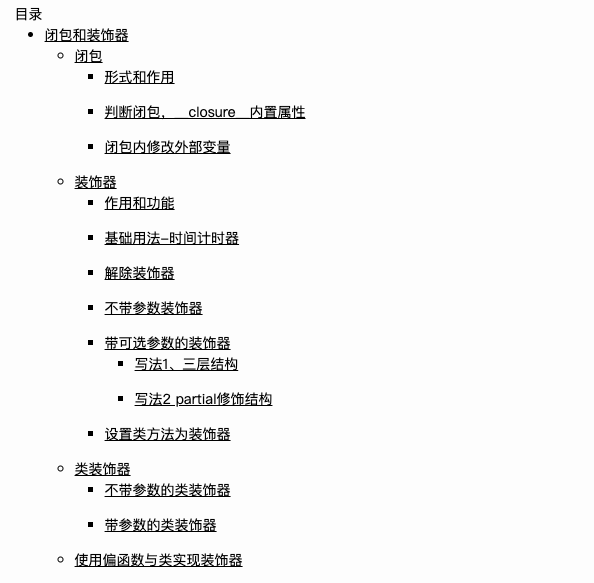

In [2]:
Image(filename='../Image/bibao_1.png')

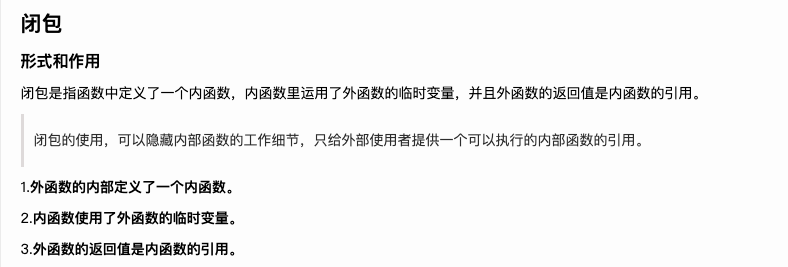

In [3]:
Image(filename='../Image/bibao_2.png')

In [ ]:
# 外部函数
def func_out(num1):
	
    # 内部函数
    def func_in(num2):
        
        # 内部函数使用外部的函数变量
        num=num1+num2
        print(num)
        return  num
    # 返回内部函数的地址
    return  func_in

func=func_out(10)

res1=func(20)
res2=func(30)

# 30
# 40


## 判断闭包，__closure__内置属性


In [ ]:
def func():
    name = 'python'
    def inner():
        print(name)
    print(inner.__closure__) 
    # (<cell at 0x0000027C14EB85E8: str object at 0x0000027C14F54960>,)
    return inner

f = func()
f()

# (<cell at 0x000002A2455DC820: str object at 0x000002A25DFD03F0>,)
# python
 


## 闭包内修改外部变量
闭包的作用——保存函数的状态信息

In [ ]:
def Maker(step):  # 包装器
    num = 1

    def fun1():  # 内部函数
        nonlocal num
        # 而是外部嵌套函数内的变量。

        num = num + step  # 改变外部变量的值
        print(num)

    return fun1


# =====================================#
j = 1
func2 = Maker(3)  # 调用外部包装器
while (j < 5):
    func2() 
    # 调用内部函数4次 输出的结果是 4、7、10、13
    j += 1




### 通常来讲，闭包的内部变量对于外界来讲是完全隐藏的。
- 但是，你可以通过编写访问函数并将其作为函数属性绑定到闭包上来实现这个目的。

In [ ]:
# 来至cookbook-p227

def sample():
    n = 0

    # Closure function
    def func():
        print('n=', n)
        # Accessor methods for n

    def get_n():
        return n

    def set_n(value):
        nonlocal n
        n = value
        # Attach as function attributes

    func.get_n = get_n
    func.set_n = set_n

    return func


f = sample()
f()

f.set_n(10)
print(f.get_n())
f()


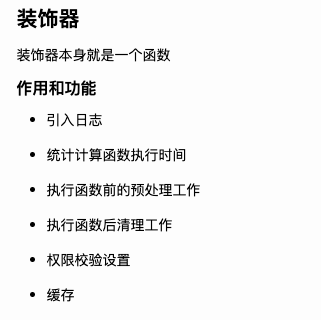

In [5]:
Image(filename='../Image/bibao_3.png')

### 基础用法-时间计时器


In [ ]:
# 这是装饰函数
from functools import wraps

def timer(func):
    @wraps
    def wrapper(*args, **kw):
        t1=time.time()
        func(*args, **kw)
        t2=time.time()

        # 计算函数执行时长
        cost_time = t2-t1 
        print("花费时间：{}秒".format(cost_time))
    return wrapper

@timeer
def add(a,b)
	return a,b

add(1,2)
# 花费时间：0秒


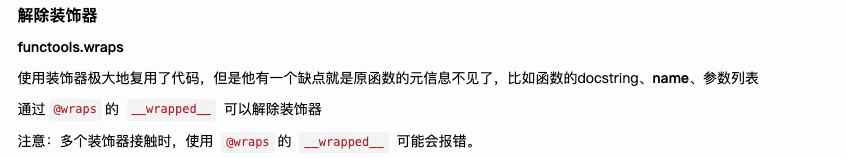

In [6]:
Image(filename='../Image/bibao_4.png')

In [7]:
from functools import wraps


def decorator(func):
    @wraps(func)  # 保存函数的元信息
    def wrapper(*args, **kwargs):
        print('Decorator 1')
        return func(*args, **kwargs)

    return wrapper

@decorator
def add(x, y):
    return x + y

res=add(3,4)
print(res)
#Decorator 1
#7
res = add.__wrapped__(2,4)  
print(res)
#6py


Decorator 1
7
6


## 不带参数装饰器


In [ ]:
# from cookbook-p302
import time
from functools import wraps

def timethis(func):
    @wraps(func)   # 保存函数的元信息
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(func.__name__, end - start)
        return result

    return wrapper


@timethis
def countdown(n):
    sumn = 0
    while n > 0:
        n -= 1
        sumn += n
    return sumn

sumn=countdown(100000)
print(sumn)
# countdown 0.009002208709716797
# 4999950000


## 带可选参数的装饰器
写法1、三层结构


In [9]:
def lggerd(msg=None):
    def dector(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            func(*args, **kwargs)
            print("调用函数", func.__name__)
            if msg:
                print(msg)

        return wrapper

    return dector


@lggerd(msg='info')
def add0(a,b):
    print(a+b)
add0(1,2)
# 调用函数 add0
# 3

@lggerd()
def add0(a,b):
    print(a+b)
add0(1,2)

# 调用函数 add0
# 3


3
调用函数 add0
info
3
调用函数 add0


这种结构的写法在使用装饰器时必须带括号 lggerd()

### 写法2 partial修饰结构

初始调用 logged() 函数时，被包装函数并没有传递进来。因此在装饰器内，它必须是可选的。这个反过来会迫使其他参数必须使用关键字来指定。并且，但这些参数被传递进来后，装饰器要返回一个接受一个函数参数并包装它的函数。为了这样做，我们使用了一个技巧，就是利用 functools.partial 。它会返回一个未完全初始化的自身，除了被包装函数外其他参数都已经确定下来了。


In [10]:
def logged(func=None, *, level=logging.DEBUG, name=None, message=None):
    if func is None:
        return partial(logged, level=level, name=name, message=message)
    logname = name if name else func.__module__
    log = logging.getLogger(logname)
    logmsg = message if message else func.__name__

    @wraps(func)
    def wrapper(*args, **kwargs):
        print("调用 wrapper")
        log.log(level, logmsg)
        return func(*args, **kwargs)

    return wrapper


# Example use
@logged
def add(x, y):
    return x + y


# print(add(1, 2))


@logged(level=logging.CRITICAL, name='example')
def spamfun():
    print('Spam!')
    return 1


NameError: name 'logging' is not defined

## 设置类方法为装饰器


In [ ]:
from functools import wraps
class A:
    # Decorator as an instance method
    def decorator1(self, func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            print('Decorator 1')
            return func(*args, **kwargs)
        return wrapper
# Decorator as a class method
    @classmethod
    def decorator2(cls, func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            print('Decorator 2')
            return func(*args, **kwargs)
        return wrapper
    
    

a = A()
@a.decorator1
def spam():
    pass
# As a class method
@A.decorator2
def grok():
    pass


## 类装饰器
- 基于类装饰器的实现，必须实现 __call__ 和 __init__两个内置函数。

- __init__ ：接收被装饰函数 __call__ ：实现装饰逻辑

### 不带参数的类装饰器

In [ ]:
class Logger(object):
    def __init__(self, func):
        self.func = func

    def __call__(self, *args, **kwargs):
        print("[INFO]: the function {func}() is running..."\
            .format(func=self.func.__name__))
        return self.func(*args, **kwargs)

@Logger
def say(something):
    print("say {}!".format(something))

say("hello")

# [INFO]: the function say() is running...
# say hello!


### 带参数的类装饰器
- 带参数和不带参数的类装饰器有很大的不同。

- __init__ ：不再接收被装饰函数，而是接收传入参数。

- __call__ ：接收被装饰函数，实现装饰逻辑。

In [ ]:
class logger(object):
    def __init__(self, level='INFO'):
        self.level = level

    def __call__(self, func): # 接受函数
        def wrapper(*args, **kwargs):
            print("[{level}]: the function {func}() is running..."\
                .format(level=self.level, func=func.__name__))
            func(*args, **kwargs)
        return wrapper  #返回函数

@logger(level='WARNING')
def say(something):
    print("say {}!".format(something))

say("hello")


### 使用偏函数与类实现装饰器
- 实现了 __call__ 的类，delay 返回一个偏函数，在这里 delay 就可以做为一个装饰器

In [ ]:
import time
import functools

class DelayFunc:
    def __init__(self,  duration, func):
        self.duration = duration
        self.func = func

    def __call__(self, *args, **kwargs):
        print(f'Wait for {self.duration} seconds...')
        time.sleep(self.duration)
        return self.func(*args, **kwargs)

    def eager_call(self, *args, **kwargs):
        print('Call without delay')
        return self.func(*args, **kwargs)

def delay(duration):
    """
    装饰器：推迟某个函数的执行。
    同时提供 .eager_call 方法立即执行
    """
    # 此处为了避免定义额外函数，
    # 直接使用 functools.partial 帮助构造 DelayFunc 实例
    return functools.partial(DelayFunc, duration)


add(3,5)  # 直接调用实例，进入 __call__
# Wait for 2 seconds...
# 8
